In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [17]:
data = loadmat('cluster_dataset.mat')

In [18]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

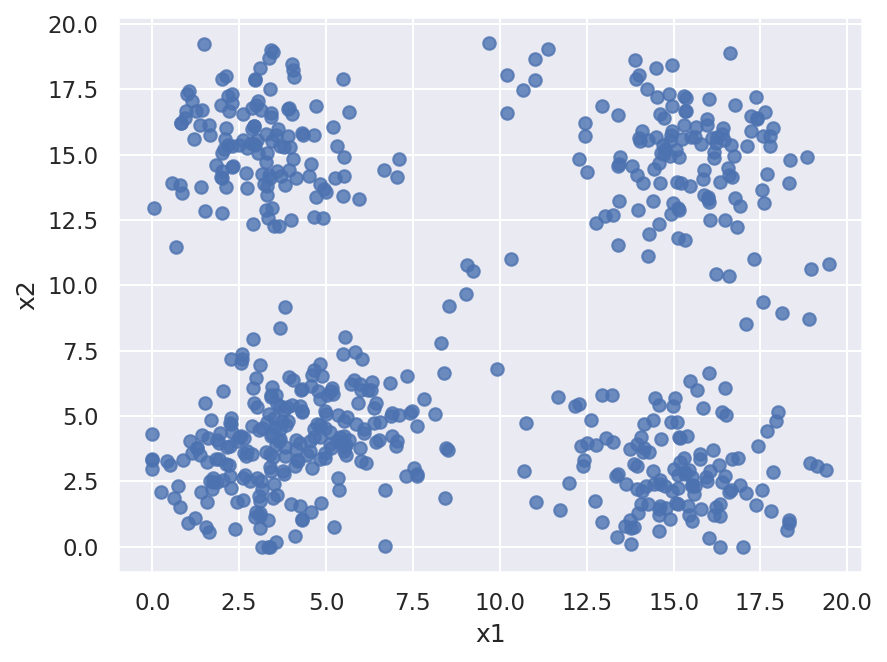

In [19]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [20]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [21]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    #"""
    #输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    #输出：centers：初始化的中心集（建议：元素为ndarray的list)
    #可能使用的函数：random.randint
    #注意：需保证随机取的样本不重复
    #"""

    #样本数量
    n = X.shape[0]
    
    #选k个不重复的索引
    idx = random.sample(range(n), k)
    
    #对应数据存入中心集
    centers = [X[i] for i in idx]

    return centers

In [22]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    #"""
    #输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    #输出：distance:欧氏距离(float/ndarray)
    #"""
    
    #计算每个样本和中心的距离
    distance = np.sqrt(np.sum(np.square(v1 - v2)))

    return distance

In [23]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    #"""
    #输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    #输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    #可能使用的函数：np.argmin
    #注意：list和array在某些计算时的转换
    #"""

    #初始化字典
    k = len(centers)
    assignment = {i: [] for i in range(k)}

    #遍历样本
    for x in X:
        #计算当前点到所有中心的距离
        distances = [distance(x, c) for c in centers]
        
        #找到距离最小的中心
        idx = np.argmin(distances)
        
        #把该点放进对应簇
        assignment[idx].append(x)
    
    return assignment

In [24]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    #"""
    #输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    #输出：cost:代价函数值（float/ndarray）
    #可能使用的函数：np.argmin
    #注意：list和array在使用np函数计算时的转换
    #"""

    total_distance = 0 #初始化总距离
    total_number = 0 #初始化总样本数

    #遍历簇
    for idx, points in assignment.items():

        #获取当前簇的中心
        center = centers[idx]
        
        #遍历这个簇里的每个点
        for p in points:

            #累加距离
            total_distance += distance(p, center)

            #累加样本数
            total_number += 1

    #求平均值
    cost = total_distance / total_number

    return cost

In [ ]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    #"""
    #输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    #输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    #可能使用的函数：np.mean
    #注意：list和array在使用np函数计算时的转换
    #"""

    k = len(centers) #簇数量
    new_centers = [] #初始化新中心
    
    #遍历簇
    for idx, points in assignment.items():

        #把点列表转成数组
        points_array = np.array(points)
        
        #计算簇内坐标均值得出新中心
        new_center = np.mean(points_array, axis=0)
        new_centers.append(new_center)
    
    #把新旧中心转成数组
    old = np.array(centers)
    new = np.array(new_centers)

    #判断新旧中心是否相同
    if np.allclose(old, new):
        stop = 1
    else:
        stop = 0
        
    return new_centers, stop

In [26]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [27]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    #"""
    #输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    #输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    #"""

    #初始化中心
    centers = init_centers(X, k)
    
    #迭代训练
    for epoch in range(max_epoch):

        #分配簇
        assignment = cluster_assignment(X, centers)

        #更新中心
        centers, stop = center_update(assignment, centers)
        
        #判断是否停机
        if stop == 1:
            print("第", epoch+1, "轮聚类中心不再改变，结束更新")
            break
    
    #计算最终代价
    cost = cost_function(assignment, centers)
    
    #聚类可视化
    plot_clustering(assignment, centers, epoch)
    
    return assignment, cost

In [28]:
max_epoch = 200 

第 4 轮聚类中心不再改变，结束更新


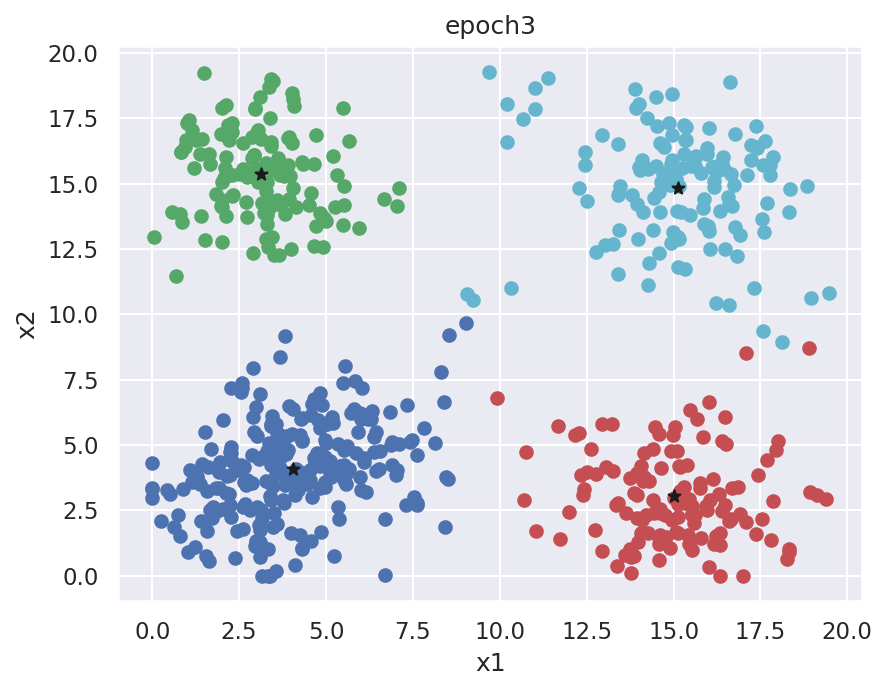

In [29]:
assignment, costnull = kmeans(X, k, max_epoch)

第 2 轮聚类中心不再改变，结束更新


<Figure size 960x720 with 0 Axes>

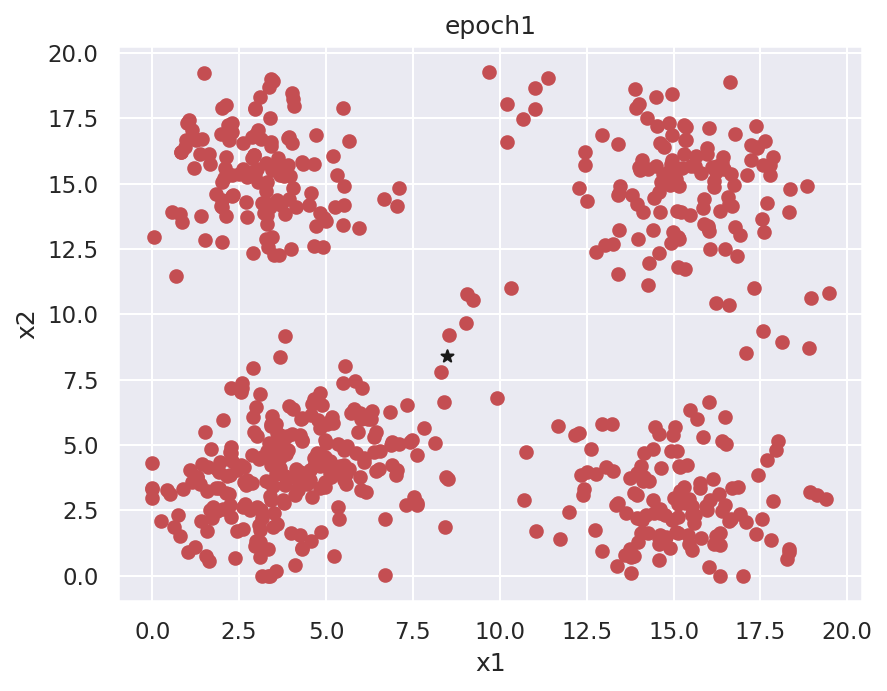

第 12 轮聚类中心不再改变，结束更新


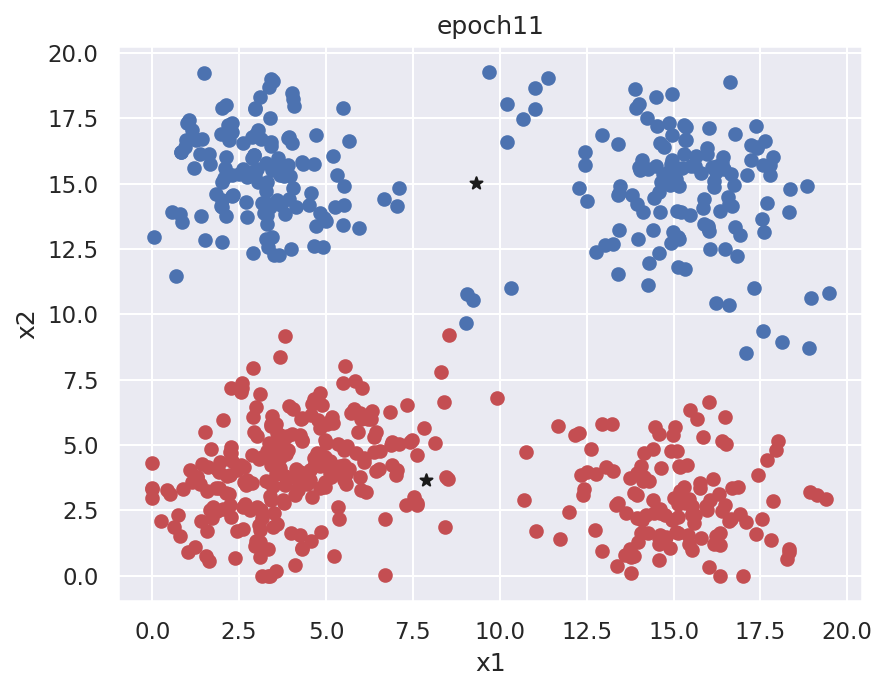

第 7 轮聚类中心不再改变，结束更新


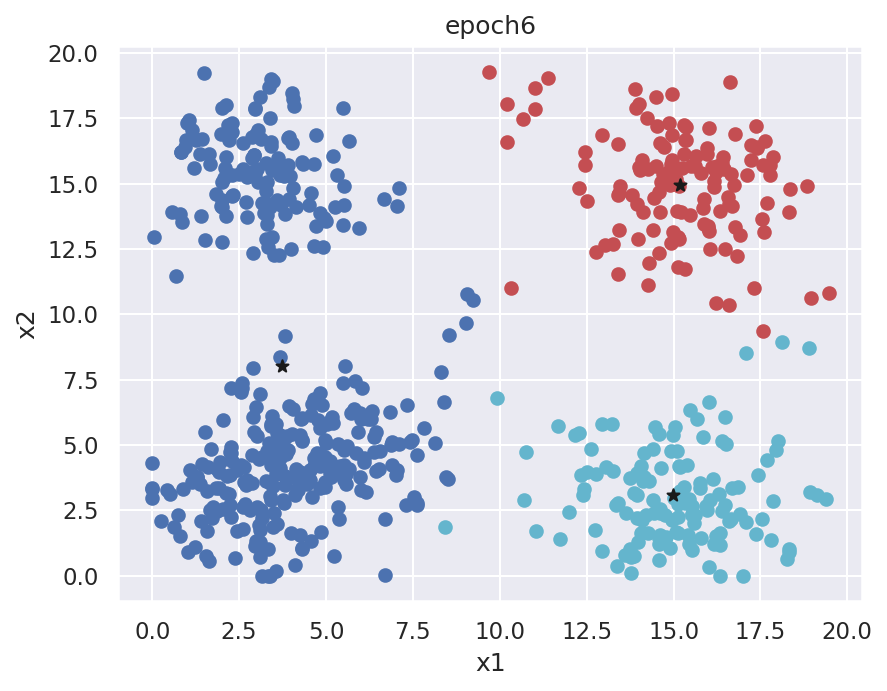

第 10 轮聚类中心不再改变，结束更新


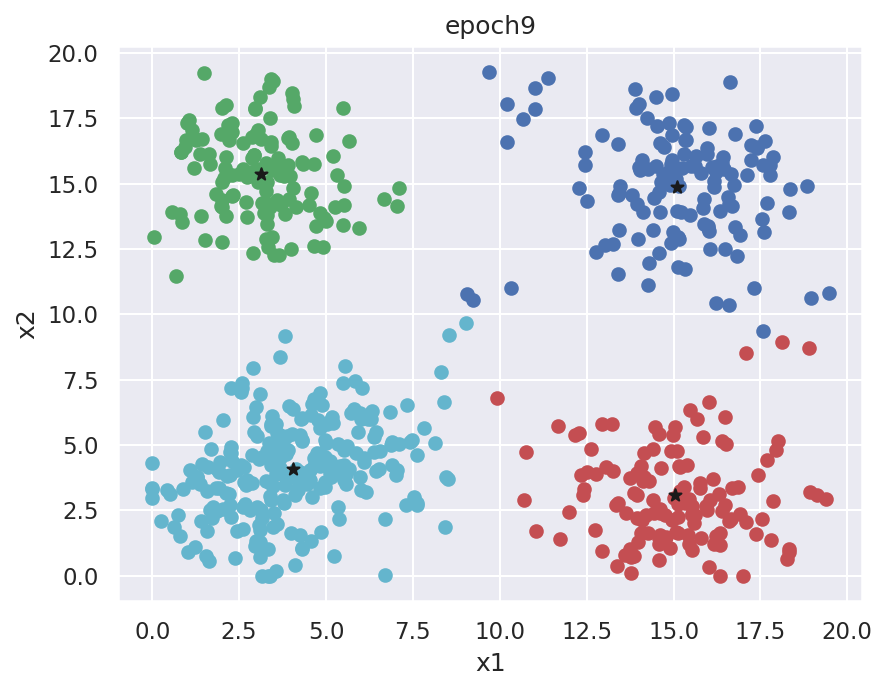

第 7 轮聚类中心不再改变，结束更新


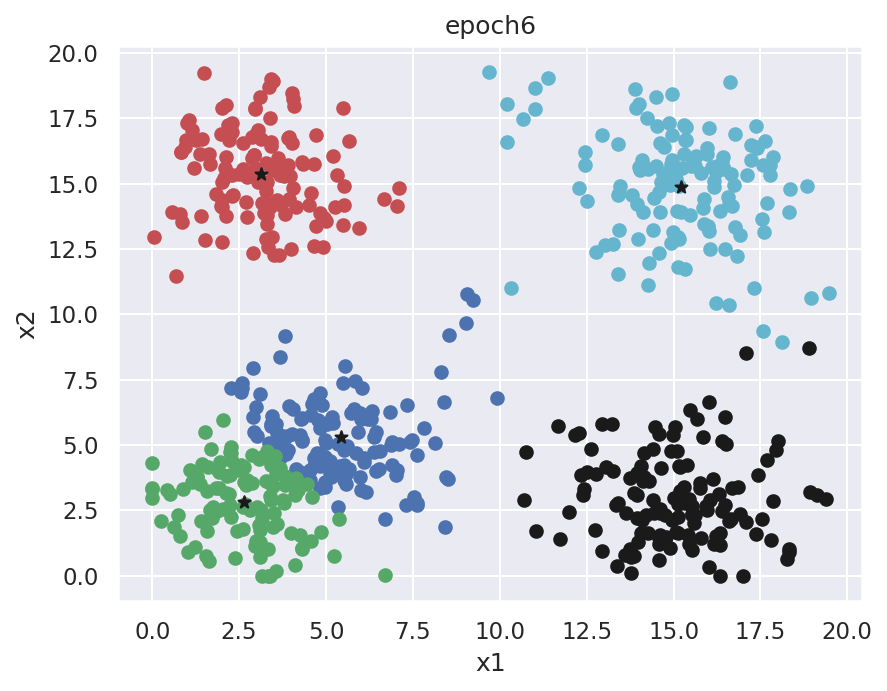

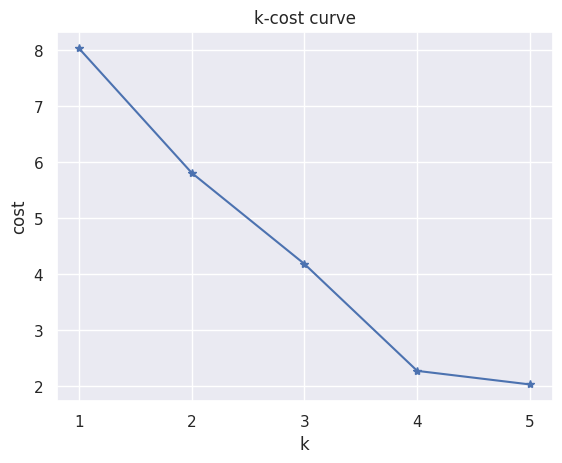

In [30]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()